In [5]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

In [6]:
# Get data
ticker_value = 'SPY'
ticker = yf.Ticker(ticker_value)
df = ticker.history(period="2y")

In [7]:
def calculate_ichimoku(df):
    # Tenkan-sen (Conversion Line): (9-period high + 9-period low)/2
    nine_period_high = df['High'].rolling(window=9).max()
    nine_period_low = df['Low'].rolling(window=9).min()
    df['tenkan_sen'] = (nine_period_high + nine_period_low) / 2

    # Kijun-sen (Base Line): (26-period high + 26-period low)/2
    period26_high = df['High'].rolling(window=26).max()
    period26_low = df['Low'].rolling(window=26).min()
    df['kijun_sen'] = (period26_high + period26_low) / 2

    # Senkou Span A (Leading Span A): (Conversion Line + Base Line)/2
    df['senkou_span_a'] = ((df['tenkan_sen'] + df['kijun_sen']) / 2).shift(26)

    # Senkou Span B (Leading Span B): (52-period high + 52-period low)/2
    period52_high = df['High'].rolling(window=52).max()
    period52_low = df['Low'].rolling(window=52).min()
    df['senkou_span_b'] = ((period52_high + period52_low) / 2).shift(26)

    # Chikou Span (Lagging Span): Current closing price shifted back 26 periods
    df['chikou_span'] = df['Close'].shift(-26)

    return df

def generate_signals(df):
    df['signal'] = 0  # 0 represents no signal
    
    # Buy signal: When Tenkan-sen crosses above Kijun-sen and price is above the cloud
    bullish_cross = (df['tenkan_sen'] > df['kijun_sen']) & \
                    (df['tenkan_sen'].shift(1) <= df['kijun_sen'].shift(1)) & \
                    (df['Close'] > df['senkou_span_a']) & \
                    (df['Close'] > df['senkou_span_b'])
    
    # Sell signal: When Tenkan-sen crosses below Kijun-sen and price is below the cloud
    bearish_cross = (df['tenkan_sen'] < df['kijun_sen']) & \
                    (df['tenkan_sen'].shift(1) >= df['kijun_sen'].shift(1)) & \
                    (df['Close'] < df['senkou_span_a']) & \
                    (df['Close'] < df['senkou_span_b'])
    
    df.loc[bullish_cross, 'signal'] = 1  # Buy signal
    df.loc[bearish_cross, 'signal'] = -1  # Sell signal
    
    return df

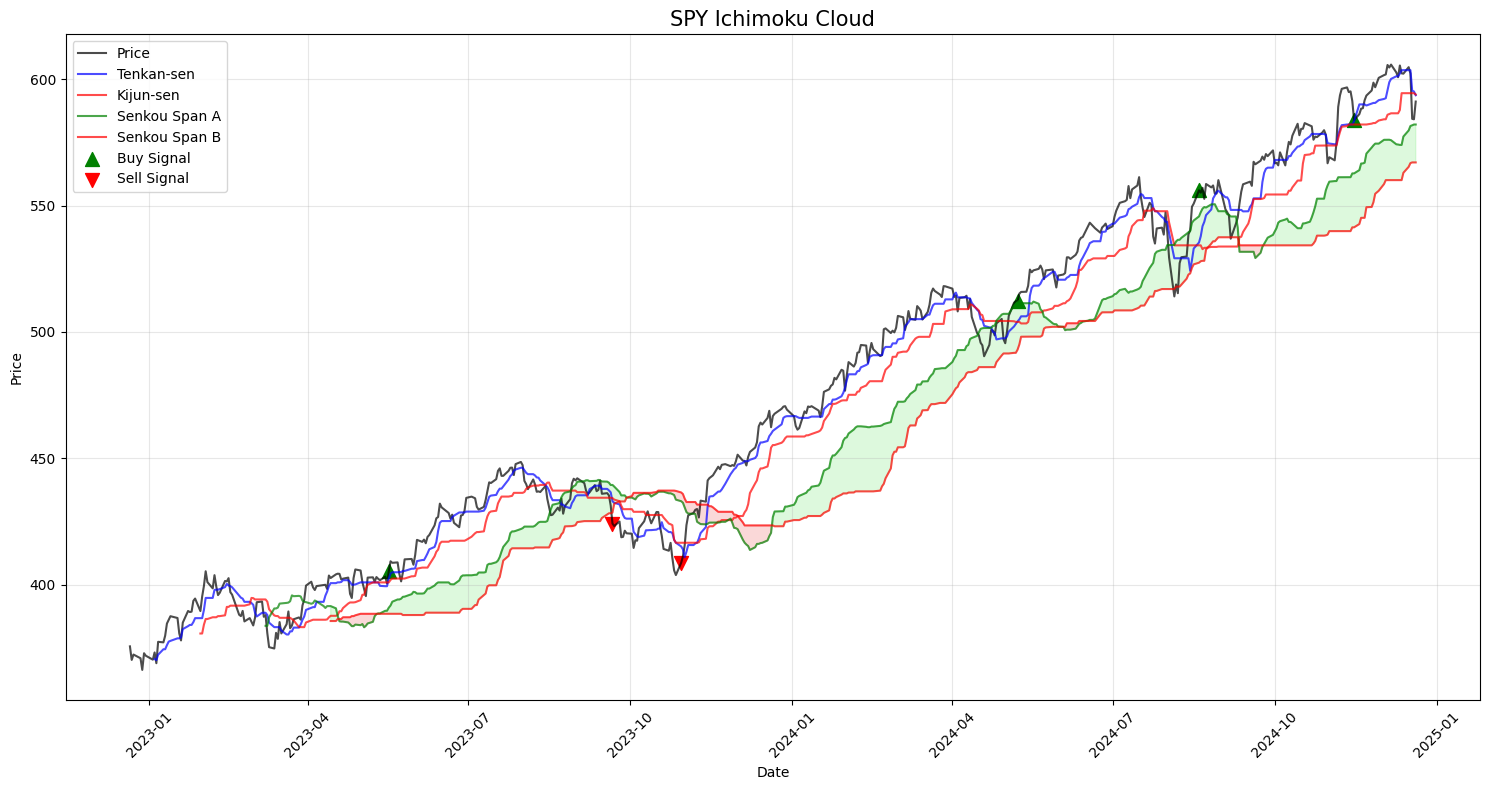


Recent Trading Signals:
                                Close Signal Type
Date                                             
2023-09-21 00:00:00-04:00  424.206604        Sell
2023-10-30 00:00:00-04:00  408.669678        Sell
2024-05-08 00:00:00-04:00  512.226440         Buy
2024-08-19 00:00:00-04:00  556.027344         Buy
2024-11-15 00:00:00-05:00  583.785156         Buy


In [8]:
# Calculate Ichimoku components and signals
df = calculate_ichimoku(df)
df = generate_signals(df)

# Create the plot
plt.figure(figsize=(15, 8))

# Plot price
plt.plot(df.index, df['Close'], label='Price', color='black', alpha=0.7)

# Plot Ichimoku components
plt.plot(df.index, df['tenkan_sen'], label='Tenkan-sen', color='blue', alpha=0.7)
plt.plot(df.index, df['kijun_sen'], label='Kijun-sen', color='red', alpha=0.7)
plt.plot(df.index, df['senkou_span_a'], label='Senkou Span A', color='green', alpha=0.7)
plt.plot(df.index, df['senkou_span_b'], label='Senkou Span B', color='red', alpha=0.7)

# Fill the cloud
plt.fill_between(df.index, df['senkou_span_a'], df['senkou_span_b'], 
                 where=df['senkou_span_a'] >= df['senkou_span_b'], 
                 color='lightgreen', alpha=0.3)
plt.fill_between(df.index, df['senkou_span_a'], df['senkou_span_b'], 
                 where=df['senkou_span_a'] < df['senkou_span_b'], 
                 color='lightcoral', alpha=0.3)

# Plot buy signals
buy_signals = df[df['signal'] == 1]
plt.scatter(buy_signals.index, buy_signals['Close'], 
           marker='^', color='green', s=100, label='Buy Signal')

# Plot sell signals
sell_signals = df[df['signal'] == -1]
plt.scatter(sell_signals.index, sell_signals['Close'], 
           marker='v', color='red', s=100, label='Sell Signal')

# Customize the plot
plt.title(f'{ticker_value} Ichimoku Cloud', fontsize=15)
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True, alpha=0.3)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Show plot
plt.show()

# Print the last few signals with their dates and prices
signals_df = df[df['signal'] != 0].copy()
signals_df['Signal Type'] = signals_df['signal'].map({1: 'Buy', -1: 'Sell'})
signals_df = signals_df[['Close', 'Signal Type']]
print("\nRecent Trading Signals:")
print(signals_df.tail().to_string())